# Protocolos de comunicação serial

### RS232

O padrão RS-232 (Recommended Standard 232) é uma norma que define a comunicação entre dispositivos seriais assíncronos.

A RS-232 especifica a interface mecânica, elétrica e funcional entre um dispositivo de transmissão de dados (como um computador ou terminal) e um dispositivo de recepção de dados (como um modem).

### USART: Universal Synchronous and Asynchronous serial Receiver and Transmitter

$\textbf{Em termos de hardware:}$
- um terra
- o $RXD$ (Receive Data)  
- o $TXD$ (Transmit Data)

Para que os dois dispositivos se comuniquem, você precisa conectar o pino TX de cada dispositivo ao pino RX do outro. Como em qualquer outro dispositivo, é importante conectar os aterramentos de ambos os dispositivos.

$\textbf{Operação:}$

O USART envia dados seriais pelo pino TX (transmissão) e escuta os dados no pino RX (recepção) usando níveis de tensão TTL (0-5 V).


A configuração mais comum é:

- Taxa de transmissão: 9600
- Bits de dados: 8
- Paridade: Nenhuma
- Bit de parada: 1
- Controle de fluxo: Nenhum

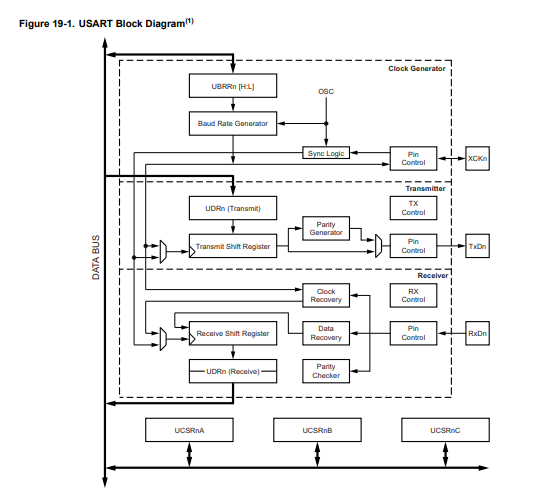

$\textbf{Partes principais}$

- **Gerador de *Clock*:**
  - Fornece lógica de sincronização para o *clock* externo usado na operação síncrona (modo escravo).
  - Inclui o gerador de *baud rate* (taxa de transmissão de dados).
  - Utiliza o pino `XCKn` apenas em modo de transferência síncrona.
  

- **Transmissor:**
  - Contém um único *write buffer* (*buffer* de escrita) para armazenar temporariamente os dados a serem transmitidos.
  - Possui *registrador de deslocamento serial*, *gerador de paridade* e lógica de controle.
  - Permite transmissão contínua de dados sem atrasos entre *frames*.

- **Receptor:**
  - Parte mais complexa, com unidades de recuperação de *clock* e dados para recepção assíncrona.
  - Inclui *verificador de paridade*, lógica de controle, *registrador de deslocamento* e *buffer* de recepção em dois níveis (`UDRn`).
  - Detecta *frame error*, *data overrun* e erros de *paridade*.

$\textbf{Modos de operação:}$

- Normal asynchronous -> não utiliza XCKn
- Double speed asynchronous -> não utiliza XCKn
- Master synchronous -> clock interno 
- Slave synchronous mode -> clock externo



### Frame 

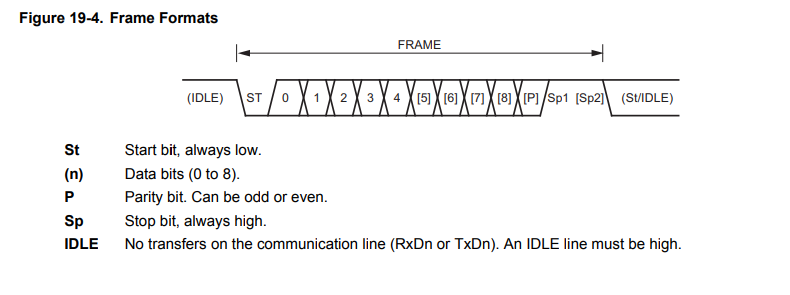


Um serial frame é composto por:

- 1 bit de início (start bit), sempre em nível baixo (0)

- 5 a 9 bits de dados

- 0, 1 bit de paridade (par ou ímpar) — opcional

- 1 ou 2 bits de parada (stop bits), sempre em nível alto (1)

o frame sempre começa com o bit de início, seguido pelo bit menos significativo (LSB) dos dados. Os bits seguintes completam a informação, terminando com o bit mais significativo (MSB). Se a paridade estiver habilitada, ela vem após os bits de dados, antes dos bits de parada.

Após o envio de um frame completo, um novo pode começar imediatamente, ou a linha pode entrar em estado IDLE (inativo), permanecendo em nível alto.

UCSZn2:0: Define o número de bits de dados por caractere (de 5 a 9 bits).

UPMn1:0: Seleciona o tipo de paridade:

- 00: Sem paridade

- 10: Paridade par

- 11: Paridade ímpar

- USBSn: Seleciona 1 ou 2 bits de parada.

Obs.: O receptor ignora o segundo stop bit. Erros de trama (frame error, FE) só são detectados quando o primeiro stop bit é 0.

### Paridade 

Paridade é uma técnica simples de detecção de erros em comunicação digital. Ela consiste em adicionar um bit extra (chamado bit de paridade) ao final de um conjunto de bits de dados para indicar se o número total de bits "1" é par ou ímpar.

| Bits de Dados      | Tipo de Paridade | Bit de Paridade | Resultado Transmitido |
| ------------------ | ---------------- | --------------- | --------------------- |
| `10110010` (4 uns) | Paridade Par     | `0`             | `101100100`           |
| `10110010` (4 uns) | Paridade Ímpar   | `1`             | `101100101`           |

Durante a recepção dos dados, o receptor conta os bits "1" e verifica se a paridade bate com o esperado:

Se não bater, um erro de paridade é detectado.

Isso não corrige o erro, apenas o detecta

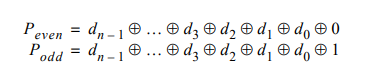

# Registradores


$\textbf{UDRn – USART I/O Data Register n}$


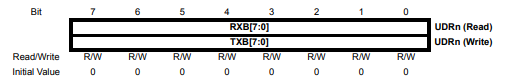

- O registrador de buffer de dados de transmissão (TXB) será o destino dos dados gravados no local do registrador UDRn.

- O registrador de buffer de dados de transmissão (TXB) será o destino dos dados gravados no local do registrador UDRn.

$\textbf{UCSRnA: Registrador de controle e status A}$



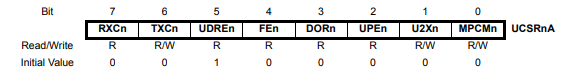

- $RXCn$: USART Receive Complete -> 1 se houver dados nao lidos no buffer e 0 se o buffer de recebimento estiver vazio

- $TXCn:$ USART Transmit Complete -> 1 se todo o frame for transmitido 

- $UDREn:$ USART Data Register Empty -> indica se o buffer esta pronto para receber novos dados



- $U2Xn$: deve ser (0) no modo de transmissão síncrona e (1) dobra a velocidade de transmissão assíncrona

> Observe, no entanto, que o receptor, neste caso, usará apenas metade do número de amostras (reduzido de 16 para 8) para amostragem de dados e recuperação de clock e, portanto, uma configuração mais precisa da taxa de transmissão e do clock do sistema são necessárias quando este modo é usado. Para o transmissor, não há desvantagens. 




$\textbf{UCSRnC: Registrador de controle e status C}$

- $UMSELn$: Seleciona o modo de operação modo assíncrono (0) ou modo síncrono (1)



$\textbf{DDR-XCKn: Registrador de direcionamento de dados}$

-  Controla se a fonte de clock é interna (modo mestre) ou externa (modo escravo).
- Quando configurado como saída (), o pino XCKn fornece o clock gerado internamente.
- Quando configurado como entrada (), recebe o clock externo para operação síncrona escrava

$\textbf{UBRRn: Registrador de taxa de transmissão (baud rate)}$

- Define o valor a ser carregado no contador decrescente. Valor diretamente relacionado à frequência do baud rate:
- Composto pelos registradores UBRRnH (parte alta) e UBRRnL (parte baixa), possibilitando configuração de 12 bits.


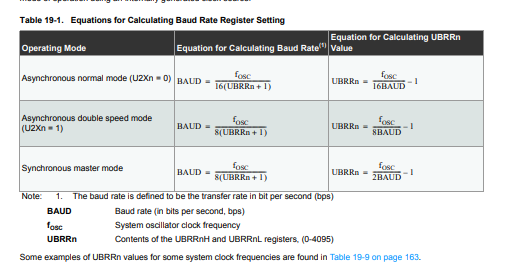

# Planejamento

1. Criar CTC de 20KHz

(TOP + 1) = fclck/(2 * fctc * N)



In [5]:
fctc = 20e3

TOP = 16e6/(2 * fctc * 8)
print(TOP)

50.0


2. Configuração do ADC

$ f_{adc} = \frac{f_{clc}}{N}$

# Telemtry Viewer (http://www.farrellf.com/TelemetryViewer/)